## Creo dataset

In [66]:
# =========================
# [1] IMPORT + SETTINGS + PATH
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mprod import table2tensor
from mprod.dimensionality_reduction import TCAM

from scipy.stats import mannwhitneyu
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"
SHEET_NAME = 0

TIMES = [1, 2, 3, 4]
TIME_TO_YEARS = {1: 0, 2: 2, 3: 4, 4: 8}
MAX_PCT_FLOOR = 80.0
FRAIL_THR = 0.25
EPS = 1e-9

OUTDIR = "tcam_compare_norms"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(f"{OUTDIR}/tables", exist_ok=True)
os.makedirs(f"{OUTDIR}/figures", exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [67]:
# =========================
# [2] LOAD FIBS
# usa riga "Feature ID" come codici colonne metaboliti
# =========================
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

code_row = raw_f.iloc[0]
name_row = raw_f.iloc[1].astype(str)
data_f   = raw_f.iloc[2:].copy()
data_f.columns = name_row

meta_cols_master = [
    "HMDB_Metabolite", "Code", "Time", "FI", "Sesso", "BMI1",
    "C_renale", "C_epatic10", "AnniScuo", "Subject"
]
meta_cols_fibs = [c for c in meta_cols_master if c in data_f.columns]

rename_fibs = {}
for j, col in enumerate(data_f.columns):
    if col in meta_cols_fibs:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    try:
        f = float(c)
        c_str = str(int(f)) if f.is_integer() else str(f)
    except:
        c_str = str(c).strip()
    rename_fibs[col] = c_str

df_fibs = data_f.rename(columns=rename_fibs).copy()

for c in ["Code", "Time", "FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")

df_fibs = df_fibs.dropna(subset=["Code", "Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()

fibs_met_cols = [c for c in df_fibs.columns if c not in meta_cols_fibs]

print("FIBS shape:", df_fibs.shape)
print("FIBS metaboliti:", len(fibs_met_cols))

FIBS shape: (3342, 97)
FIBS metaboliti: 88


In [68]:
# =========================
# [3] LOAD MICROBIOTA
# normalizza colonne + codici metaboliti come stringhe
# =========================
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]

micro = micro.rename(columns={
    "TIME": "Time", "time": "Time",
    "ID Code": "Code", "CODE": "Code", "code": "Code"
})

micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore").copy()

micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code", "Time"]).copy()

micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()

micro_met_cols = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]

def norm_code(x):
    try:
        f = float(x)
        return str(int(f)) if f.is_integer() else str(f)
    except:
        return str(x).strip()

micro = micro.rename(columns={c: norm_code(c) for c in micro_met_cols})
micro_met_cols = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]

micro[micro_met_cols] = micro[micro_met_cols].apply(pd.to_numeric, errors="coerce")

print("MICRO shape:", micro.shape)
print("MICRO metaboliti:", len(micro_met_cols))

MICRO shape: (3403, 110)
MICRO metaboliti: 107


In [69]:
# =========================
# [4] RIMUOVI DUPLICATI metaboliti
# se il codice esiste già in FIBS, lo tolgo da Microbiota
# =========================
dup_codes = sorted(list(set(micro_met_cols).intersection(set(fibs_met_cols))))
if dup_codes:
    print("Duplicati tolti da Microbiota:", len(dup_codes))
    micro = micro.drop(columns=dup_codes).copy()

micro_met_cols = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
print("MICRO metaboliti dopo dedup:", len(micro_met_cols))

Duplicati tolti da Microbiota: 2
MICRO metaboliti dopo dedup: 105


In [70]:
# =========================
# [5] TIENI SOLO PAZIENTI COMPLETI IN ENTRAMBI
# =========================
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code", "Time"]])
cc_micro = complete_codes(micro[["Code", "Time"]])
common   = sorted(list(cc_fibs & cc_micro))

print("Pazienti completi FIBS:", len(cc_fibs))
print("Pazienti completi MICRO:", len(cc_micro))
print("Intersezione usata:", len(common))

df_fibs_c = df_fibs[df_fibs["Code"].isin(common)].copy()
micro_c   = micro[micro["Code"].isin(common)].copy()

df = df_fibs_c.merge(micro_c, on=["Code", "Time"], how="inner")

print("DF finale:", df.shape)
print("Pazienti:", df["Code"].nunique())
print("Righe:", len(df))
print("Time:", sorted(df["Time"].unique()))

Pazienti completi FIBS: 610
Pazienti completi MICRO: 609
Intersezione usata: 609
DF finale: (2436, 203)
Pazienti: 609
Righe: 2436
Time: [1, 2, 3, 4]


In [71]:
# =========================
# [7] META VS METABOLITI
# =========================
meta_cols = [c for c in meta_cols_master if c in df.columns]

keep_meta = ["Code", "Time"]
if "FI" in df.columns:
    keep_meta.append("FI")

for c in meta_cols:
    if c not in keep_meta:
        keep_meta.append(c)

met_cols_all = [c for c in df.columns if c not in keep_meta]

df[met_cols_all] = df[met_cols_all].apply(pd.to_numeric, errors="coerce")

print("Meta columns:", keep_meta)
print("Metaboliti totali:", len(met_cols_all))
print("Prime colonne metaboliti:", met_cols_all[:10])

Meta columns: ['Code', 'Time', 'FI', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject']
Metaboliti totali: 193
Prime colonne metaboliti: ['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087']


In [72]:
# =========================
# [8] FILTER 1
# togli metaboliti con almeno 1 NaN
# =========================
nan_any = df[met_cols_all].isna().any(axis=0)

mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()

print("Metaboliti con >=1 NaN:", len(mets_with_nan))
print("Metaboliti senza NaN:", len(mets_no_nan))

df_nn = df[keep_meta + mets_no_nan].copy()
met_cols_nn = mets_no_nan

print("df_nn shape:", df_nn.shape)

Metaboliti con >=1 NaN: 0
Metaboliti senza NaN: 193
df_nn shape: (2436, 203)


In [73]:
# =========================
# [9] FILTER 2
# floor = minimo della colonna
# togli % floor > 50
# =========================
floors = df_nn[met_cols_nn].min(axis=0)
is_floor = df_nn[met_cols_nn].eq(floors, axis=1)
pct_floor = is_floor.mean(axis=0) * 100

mets_high_floor = pct_floor[pct_floor > MAX_PCT_FLOOR].index.tolist()
mets_ok_floor   = pct_floor[pct_floor <= MAX_PCT_FLOOR].index.tolist()

print("Metaboliti con % floor > 50:", len(mets_high_floor))
print("Metaboliti finali:", len(mets_ok_floor))

df_eda = df_nn[keep_meta + mets_ok_floor].copy()
met_cols_eda = mets_ok_floor

print("DF EDA finale:", df_eda.shape)
print("Pazienti:", df_eda["Code"].nunique())
print("Time:", sorted(df_eda["Time"].unique()))

Metaboliti con % floor > 50: 82
Metaboliti finali: 111
DF EDA finale: (2436, 121)
Pazienti: 609
Time: [1, 2, 3, 4]


In [74]:
# =========================
# [10] RINOMINA SOLO I METABOLITI FIBS
# feature_id -> nome
# =========================
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

feature_row = raw_f.iloc[0]
name_row    = raw_f.iloc[1].astype(str)

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]

fibs_code_to_name = {}

for j in range(len(name_row)):
    nm = str(name_row.iloc[j]).strip()
    if nm in meta_cols_master:
        continue

    fid = feature_row.iloc[j]
    if pd.isna(fid):
        continue

    try:
        f = float(fid)
        fid_str = str(int(f)) if f.is_integer() else str(f)
    except:
        fid_str = str(fid).strip()

    fibs_code_to_name[fid_str] = nm

rename_after_eda = {c: fibs_code_to_name[c] for c in met_cols_eda if c in fibs_code_to_name}

name_counts = pd.Series(rename_after_eda.values()).value_counts()
dup_names = name_counts[name_counts > 1].index.tolist()

if len(dup_names) > 0:
    print("Nomi duplicati in FIBS: lascio il codice per sicurezza")
    for old_code, new_name in list(rename_after_eda.items()):
        if new_name in dup_names:
            rename_after_eda[old_code] = old_code

df_eda = df_eda.rename(columns=rename_after_eda).copy()
met_cols_eda = [rename_after_eda.get(c, c) for c in met_cols_eda]

print("Metaboliti FIBS rinominati:", len(rename_after_eda))
print("Numero metaboliti finali:", len(met_cols_eda))

Metaboliti FIBS rinominati: 53
Numero metaboliti finali: 111


In [75]:
# =========================
# [11] EVER-FRAIL VS NEVER-FRAIL
# =========================
df_eda["FI"] = pd.to_numeric(df_eda["FI"], errors="coerce")

ever_frail_map = (
    df_eda.groupby("Code")["FI"]
    .apply(lambda s: (s > FRAIL_THR).any())
    .to_dict()
)

df_eda["frail_group"] = df_eda["Code"].map(
    lambda x: "Ever-frail" if ever_frail_map[x] else "Never-frail"
)

group_counts = (
    df_eda[["Code", "frail_group"]]
    .drop_duplicates()["frail_group"]
    .value_counts()
)

print(group_counts)

df_eda["Years"] = df_eda["Time"].map(TIME_TO_YEARS)
display(df_eda.head())

frail_group
Never-frail    467
Ever-frail     142
Name: count, dtype: int64


,Code,Time,FI,HMDB_Metabolite,Sesso,BMI1,C_renale,C_epatic10,AnniScuo,Subject,Chalconaringenin;,1-Methylxanthine; 9-Methylxanthine; 7-Methylxanthine; 3-Methylxanthine; 1-methylxanthine; 3-methylxanthine; 7-methylxanthine;,"2,4-Dihydroxy-2H-1,4-benzoxazin-3(4H)-one DIBOA","(2E,4E)-2,4-Hexadienoic acid (sorbic acid)",Benzoic acid,Campesteryl p-coumarate,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,4'-Methylepicatechin 3'-sulfate,Methylgallic acid-O-sulphate,Butylparaben,"3-Methyl-1-(2,4,6-trihydroxyphenyl)-1-butanone",Pyrogallol,6-Hydroxypseudooxynicotine,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone",Acesulfame; Acesulfame K;,Carnosine,Hydroxycotinine,Caffeine,Daidzein,Enterodiol,Enterolactone; Enterolactone;,Ethyl glucuronide,Hordenine,Hydroxytyrosol 1-O-glucoside,"L,L-Cyclo(leucylprolyl)",Pinoresinol,Naringenin 5-sulfate,Nicotine-1'-N-oxide,Nicotine; Nicotine;,Phloretin,Piperine,Resveratrol,Secoisolariciresinol,Sulforaphane,Uric acid,Resveratrol-O-glucuronide,2-Hydroxycinnamic acid,Pyridoxine (vitamine B6),Gallic acid,Hippuric acid,myo-Inositol,7-Methyluric acid; 9-Methyluric acid; 1-Methyluric acid; 1-methyluric acid; 3-methyluric acid; 7-methyluric acid;,Saccharin,Syringic acid,5-acetylamino-6-amino-3-methyluracil ((AAMU),Sinapic acid,Vanillin 4-sulfate,Eicosapentaenoic acid,Arachidonic acid,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),Eicosadienoic acid (cis-20:2n-6),Isorhamnetin,Urolithin C 3-glucuronide,53981,62745,65715,68671,70569,75706,75712,77351,86199,86252,86784,88195,88933,91522,97037,97573,103418,103971,105164,107237,108055,108945,111333,119981,121399,121512,122342,122847,123687,124023,125107,125734,126048,127931,127942,127949,128253,128853,129151,130376,130381,131646,133960,136343,136611,136614,138147,141191,142168,142174,144134,146373,146387,146712,147158,150916,96893,125401,frail_group,Years
0,9,1,0.060606,int_9,2,23.12467,1,1,12,int_9,0.12,0.24,0.02,234.60,3639.20,0.06,6492.7,0.02,873.40,0.14,295.00,1.46,569.60,0.3,86.30,176.40,0.02,0.06,2280.9,1602.3,0.04,0.02,0.06,0.06,0.06,54.7,0.86,0.06,0.12,2698.30,0.02,0.06,208.7,10302.30,18152.1,250.10,6964.7,0.04,0.06,1.2,207.2,9309874.00,0.16,0.1,2.26,0.02,2.22,0.02,0.66,0.06,0.04,5.84,4.0,52863.60,0.24,0.36,1.62,4199.30,1.32,0.08,0.02,0.5,0.06,569.40,1914.10,0.06,0.02,186.90,0.6,0.08,8718.0,0.02,4.18,17.70,0.6,0.1,291.70,6.0,13179.9,43.8,0.22,25.70,318.20,124.80,0.34,0.06,842.90,0.34,0.02,0.12,0.02,1561.70,0.26,0.16,0.14,97856.4,0.28,1.06,0.28,292.60,0.02,0.06,0.08,42.70,0.06,0.06,0.02,0.02,0.02,0.88,0.08,Never-frail,0
1,9,2,0.060606,int_2_9,NaN,23.733214,1,1,NaN,int_2_9,527.00,0.24,0.02,0.04,3262.80,187.80,6380.9,0.02,0.08,55.20,88.80,3127.70,79.70,0.3,37.30,124.30,77.70,0.06,9678.2,144.8,0.04,0.02,28.30,36.70,40.10,0.1,0.86,124.70,0.12,10247.40,0.02,199.50,0.1,10901.60,5879.2,110.40,9701.6,2.50,0.06,12410.5,85151.5,3.82,607.40,0.1,80.00,0.02,185.00,3830.90,46178.00,12552.10,7353.70,18494.20,4.0,1.94,0.24,0.36,1.62,128.70,1.32,0.08,67.80,0.5,747.30,0.04,1257.20,0.06,0.02,0.12,0.6,140.90,748.1,0.02,678.00,90.30,0.6,58.9,0.22,5040.8,5254.0,31.8,167.90,4.30,73.70,153.00,0.34,70.70,60.50,0.34,0.02,0.12,436.90,33.40,0.26,0.16,43.80,121.3,756.60,1636.30,0.28,0.24,276.30,0.06,34.70,0.34,30.50,0.06,0.02,0.02,0.02,3210.50,751.70,Never-frail,2
2,9,3,0.060606,int_4_9,NaN,23.936062,1,1,NaN,int_4_9,0.12,0.24,0.02,1211857.70,996.90,0.06,6249.1,0.02,0.08,147835.00,0.34,167126.80,0.02,0.3,0.02,0.02,98.70,22483.20,996.8,3678.7,522.40,0.02,0.06,2106.60,0.06,356848.7,0.86,0.06,0.12,34104.90,0.02,0.06,14146.8,0.02,2505.9,0.52,7834.5,0.04,0.06,16438.2,68943.1,3.82,893.70,18.4,1397.00,118.60,2859.40,0.02,2824.00,193.70,0.04,14540.00,62.2,1.94,411604.40,190.40,1.62,257.90,1.32,9.10,0.02,73595.4,0.06,154.50,0.64,0.06,0.02,0.12,13052.5,0.08,1.2,17.20,1138.80,0.08,0.6,0.1,0.22,7044.9,0.7,2872.4,186502.20,0.06,0.02,0.02,0.34,0.06,513.60,4408.60,0.02,608818.90,129.20,0.04,2518.40,3677.70,24018.80,40163.9,3476.30,1.06,7341.10,317.90,0.02,0.06,0.08,49

## TCAM

In [84]:
# =========================
# [12] DFB NORMALIZATION
# come nel caso proteomico del paper
# =========================
from scipy.stats import ttest_ind

def apply_dfb(df_vals, subject_col="Code", time_col="Time", baseline_time=1):
    """
    DFB = deviation from baseline
    per ogni soggetto e feature:
    x_t - x_baseline
    """
    X = df_vals.copy()
    feat_cols = [c for c in X.columns if c not in [subject_col, time_col]]

    baseline = (
        X[X[time_col] == baseline_time]
        .drop(columns=[time_col])
        .set_index(subject_col)
    )

    out = X.copy()
    for c in feat_cols:
        out[c] = X[c] - X[subject_col].map(baseline[c])

    return out

def drop_bad_features(df_in, meta_cols):
    feat_cols = [c for c in df_in.columns if c not in meta_cols]

    nan_any = df_in[feat_cols].isna().any(axis=0)
    feat_cols = [c for c in feat_cols if not nan_any[c]]

    stds = df_in[feat_cols].std(axis=0, ddof=1)
    feat_cols = [c for c in feat_cols if stds[c] > 0]

    df_out = df_in[meta_cols + feat_cols].copy()
    return df_out, feat_cols

meta_cols_tcam = ["Code", "Time", "Years", "frail_group"]

df_dfb = df_eda[meta_cols_tcam + met_cols_eda].copy()

# DFB su metaboliti raw, come logica del paper proteomics
tmp_dfb = apply_dfb(
    df_dfb[["Code", "Time"] + met_cols_eda],
    subject_col="Code",
    time_col="Time",
    baseline_time=1
)

df_dfb = pd.concat([df_dfb[meta_cols_tcam], tmp_dfb[met_cols_eda]], axis=1)
df_dfb, met_cols_dfb = drop_bad_features(df_dfb, meta_cols_tcam)

print("Metaboliti iniziali:", len(met_cols_eda))
print("Metaboliti usati dopo DFB:", len(met_cols_dfb))
print("Metaboliti tolti:", len(met_cols_eda) - len(met_cols_dfb))

display(df_dfb.head())

Metaboliti iniziali: 111
Metaboliti usati dopo DFB: 111
Metaboliti tolti: 0


,Code,Time,Years,frail_group,Chalconaringenin;,1-Methylxanthine; 9-Methylxanthine; 7-Methylxanthine; 3-Methylxanthine; 1-methylxanthine; 3-methylxanthine; 7-methylxanthine;,"2,4-Dihydroxy-2H-1,4-benzoxazin-3(4H)-one DIBOA","(2E,4E)-2,4-Hexadienoic acid (sorbic acid)",Benzoic acid,Campesteryl p-coumarate,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,4'-Methylepicatechin 3'-sulfate,Methylgallic acid-O-sulphate,Butylparaben,"3-Methyl-1-(2,4,6-trihydroxyphenyl)-1-butanone",Pyrogallol,6-Hydroxypseudooxynicotine,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone",Acesulfame; Acesulfame K;,Carnosine,Hydroxycotinine,Caffeine,Daidzein,Enterodiol,Enterolactone; Enterolactone;,Ethyl glucuronide,Hordenine,Hydroxytyrosol 1-O-glucoside,"L,L-Cyclo(leucylprolyl)",Pinoresinol,Naringenin 5-sulfate,Nicotine-1'-N-oxide,Nicotine; Nicotine;,Phloretin,Piperine,Resveratrol,Secoisolariciresinol,Sulforaphane,Uric acid,Resveratrol-O-glucuronide,2-Hydroxycinnamic acid,Pyridoxine (vitamine B6),Gallic acid,Hippuric acid,myo-Inositol,7-Methyluric acid; 9-Methyluric acid; 1-Methyluric acid; 1-methyluric acid; 3-methyluric acid; 7-methyluric acid;,Saccharin,Syringic acid,5-acetylamino-6-amino-3-methyluracil ((AAMU),Sinapic acid,Vanillin 4-sulfate,Eicosapentaenoic acid,Arachidonic acid,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),Eicosadienoic acid (cis-20:2n-6),Isorhamnetin,Urolithin C 3-glucuronide,53981,62745,65715,68671,70569,75706,75712,77351,86199,86252,86784,88195,88933,91522,97037,97573,103418,103971,105164,107237,108055,108945,111333,119981,121399,121512,122342,122847,123687,124023,125107,125734,126048,127931,127942,127949,128253,128853,129151,130376,130381,131646,133960,136343,136611,136614,138147,141191,142168,142174,144134,146373,146387,146712,147158,150916,96893,125401
0,9,1,0,Never-frail,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00
1,9,2,2,Never-frail,526.88,0.00,0.0,-234.56,-376.40,187.74,-111.8,0.00,-873.32,55.06,-206.20,3126.24,-489.90,0.0,-49.00,-52.10,77.68,0.00,7397.3,-1457.5,0.00,0.0,28.24,36.64,40.04,-54.6,0.00,124.64,0.0,7549.10,0.0,199.44,-208.6,599.30,-12272.9,-139.70,2736.9,2.46,0.0,12409.3,84944.3,-9309870.18,607.24,0.0,77.74,0.00,182.78,3830.88,46177.34,12552.04,7353.66,18488.36,0.0,-52861.66,0.00,0.00,0.00,-4070.60,0.0,0.00,67.78,0.0,747.24,-569.36,-656.90,0.00,0.00,-186.78,0.0,140.82,-7969.9,0.00,673.82,72.60,0.0,58.8,-291.48,5034.8,-7925.9,-12.0,167.68,-21.40,-244.50,28.20,0.0,70.64,-782.4,0.00,0.0,0.00,436.88,-1528.30,0.00,0.00,43.66,-97735.1,756.32,1635.24,0.00,-292.36,276.28,0.00,34.62,-42.36,30.44,0.00,0.0,0.00,0.0,3209.62,751.62
2,9,3,4,Never-frail,0.00,0.00,0.0,1211623.10,-2642.30,0.00,-243.6,0.00,-873.32,147834.86,-294.66,167125.34,-569.58,0.0,-86.28,-176.38,98.68,22483.14,-1284.1,2076.4,522.36,0.0,0.00,2106.54,0.00,356794.0,0.00,0.00,0.0,31406.60,0.0,0.00,13938.1,-10302.28,-15646.2,-249.58,869.8,0.00,0.0,16437.0,68735.9,-9309870.18,893.54,18.3,1394.74,118.58,2857.18,0.00,2823.34,193.64,0.00,14534.16,58.2,-52861.66,411604.16,190.04,0.00,-3941.40,0.0,9.02,0.00,73594.9,0.00,-414.90,-1913.46,0.00,0.00,-186.78,13051.9,0.00,-8716.8,17.18,1134.62,-17.62,0.0,0.0,-291.48,7038.9,-13179.2,2828.6,186501.98,-25.64,-318.18,-124.78,0.0,0.00,-329.3,4408.26,0.0,608818.78,129.18,-1561.66,2518.14,3677.54,24018.66,-57692.5,3476.02,0.00,7340.82,25.30,0.00,0.00,0.00,4921.20,0.00,0.00,0.0,44.28,0.0,5199.82,0.00
3,9,4,8,Never-frail,0.00,181.46,0.0,3714.30,-3638.98,0.00,1964.2,283.88,-873.32,0.00,-294.66,0.00,-569.58,3028.2,-86.28,120.20,12

In [86]:
# =========================
# [13] TABLE -> TENSOR -> TCAM
# =========================
data_table = (
    df_dfb
    .set_index(["Code", "Time"])[met_cols_dfb]
    .sort_index()
    .copy()
)

print("Shape data_table:", data_table.shape)
display(data_table.head())

data_tensor, map_subject, map_time = table2tensor(data_table)

print("Tensor shape:", data_tensor.shape)
print("n_subjects:", len(map_subject))
print("n_timepoints:", len(map_time))

tcam = TCAM()
scores = tcam.fit_transform(data_tensor)

expl_var = pd.Series(
    tcam.explained_variance_ratio_,
    index=[f"F{i+1}" for i in range(len(tcam.explained_variance_ratio_))]
)

print("Scores shape:", scores.shape)
display(expl_var.head(10).to_frame("explained_variance_ratio"))

Shape data_table: (2436, 111)


Chalconaringenin;  \
Code Time                      
9    1                  0.00   
     2                526.88   
     3                  0.00   
     4                  0.00   
11   1                  0.00   

           1-Methylxanthine; 9-Methylxanthine; 7-Methylxanthine; 3-Methylxanthine; 1-methylxanthine; 3-methylxanthine; 7-methylxanthine;  \
Code Time                                                                                                                                  
9    1                                                  0.00                                                                               
     2                                                  0.00                                                                               
     3                                                  0.00                                                                               
     4                                                181.46                                                                               
11   1                                                  0.00                                                                               

           2,4-Dihydroxy-2H-1,4-benzoxazin-3(4H)-one DIBOA  \
Code Time                                                    
9    1                                                 0.0   
     2                                                 0.0   
     3                                                 0.0   
     4                                                 0.0   
11   1                                                 0.0   

           (2E,4E)-2,4-Hexadienoic acid (sorbic acid)  Benzoic acid  \
Code Time                                                             
9    1                                           0.00          0.00   
     2                                        -234.56       -376.40   
     3                                     1211623.10      -2642.30   
     4                                        3714.30      -3638.98   
11   1                                           0.00          0.00   

           Campesteryl p-coumarate  \
Code Time                            
9    1                        0.00   
     2                      187.74   
     3                        0.00   
     4                        0.00   
11   1                        0.00   

           3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;  \
Code Time                                                                                
9    1                                                   0.0                             
     2                                                -111.8                             
     3                                                -243.6                             
     4                                                1964.2                             
11   1                                                   0.0                             

           4'-Methylepicatechin 3'-sulfate  Methylgallic acid-O-sulphate  \
Code Time                                                                  
9    1                                0.00                          0.00   
     2                                0.00                       -873.32   
     3                                0.00                       -873.32   
     4                              283.88                       -873.32   
11   1                                0.00                          0.00   

           Butylparaben  3-Methyl-1-(2,4,6-trihydroxyphenyl)-1-butanone  \
Code Time                                                                 
9    1             0.00                                            0.00   
     2            55.06                                         -206.20   
     3        147834.86                                         -294.66   
     4             0.00                                         -2

Tensor shape: (609, 111, 4)
n_subjects: 609
n_timepoints: 4
Scores shape: (609, 443)


,explained_variance_ratio
F1,0.426135
F2,0.278283
F3,0.080835
F4,0.052784
F5,0.047347
F6,0.030921
F7,0.027015
F8,0.013866
F9,0.010990
F10,0.009057


In [87]:
# =========================
# [14] SCORES DATAFRAME
# =========================
inv_subject_map = {v: k for k, v in map_subject.items()}

scores_df = pd.DataFrame(
    scores,
    index=[inv_subject_map[i] for i in range(scores.shape[0])],
    columns=[f"F{i+1}" for i in range(scores.shape[1])]
)

scores_df.index.name = "Code"
scores_df = scores_df.reset_index()

group_df = df_dfb[["Code", "frail_group"]].drop_duplicates()
scores_df = scores_df.merge(group_df, on="Code", how="left")

display(scores_df.head())

scores_df.to_csv(f"{OUTDIR}/tables/tcam_scores_dfb.tsv", sep="\t", index=False)
expl_var.to_csv(f"{OUTDIR}/tables/tcam_explained_variance_dfb.tsv", sep="\t")

,Code,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49,F50,F51,F52,F53,F54,F55,F56,F57,F58,F59,F60,F61,F62,F63,F64,F65,F66,F67,F68,F69,F70,F71,F72,F73,F74,F75,F76,F77,F78,F79,F80,F81,F82,F83,F84,F85,F86,F87,F88,F89,F90,F91,F92,F93,F94,F95,F96,F97,F98,F99,...,F345,F346,F347,F348,F349,F350,F351,F352,F353,F354,F355,F356,F357,F358,F359,F360,F361,F362,F363,F364,F365,F366,F367,F368,F369,F370,F371,F372,F373,F374,F375,F376,F377,F378,F379,F380,F381,F382,F383,F384,F385,F386,F387,F388,F389,F390,F391,F392,F393,F394,F395,F396,F397,F398,F399,F400,F401,F402,F403,F404,F405,F406,F407,F408,F409,F410,F411,F412,F413,F414,F415,F416,F417,F418,F419,F420,F421,F422,F423,F424,F425,F426,F427,F428,F429,F430,F431,F432,F433,F434,F435,F436,F437,F438,F439,F440,F441,F442,F443,frail_group
0,9,-1.546155e+06,296784.713291,-674591.028852,129386.923122,-514517.222946,-98791.064429,-1.370548e+07,-278490.882980,1.062721e+06,-53963.929023,39027.826958,5.974558e+06,4.578707e+06,393650.920530,449192.735315,-13419.135454,2.521552e+06,-14755.768966,312370.022598,2381.635046,6966.475121,-47594.308042,-67004.872158,6231.718940,9942.748268,-54205.045337,113747.762231,11325.977219,107583.493835,-8808.173584,-72942.120083,-86145.070973,18303.570195,761825.246641,59358.056628,206023.339476,143110.955780,143762.108147,-429057.901784,-102111.888079,563504.969049,-353302.414566,-159473.945616,12765.146474,9723.320191,-3562.577716,3006.933423,-1891.532285,156474.909446,-3459.368469,-5671.065957,-8796.408131,-5556.622529,-278092.929169,9714.147029,-5051.147819,14535.194104,11184.910119,-13872.443962,14599.465549,10358.900712,-82331.075814,17737.692689,8143.217819,-17757.593984,17223.037459,-69851.986998,-2733.849918,-64124.100384,8185.716978,17823.412896,3240.576962,18967.609992,-3618.096072,2501.445066,-16462.119854,21650.949888,41607.531603,28115.453512,-1559.554134,-4520.416172,4739.392241,10741.691243,643.927953,-7988.650069,-3207.645469,-2224.116028,-4475.496178,10361.346644,4263.822567,-12032.330376,11415.992706,6574.977398,273.604108,-2443.789084,-18417.405829,-3543.446859,7171.342183,-2126.646734,...,-50.425895,4.974074,-202.582652,-79.359085,58.129610,27.905014,-79.104090,1.530688,-15.665864,-234.132751,6.115210,-52.424510,-134.262477,26.820315,36.364430,-7.423322,44.493380,238.714059,42.046714,-20.208734,-142.130902,9.865796,-31.778152,26.030454,123.072338,-10.156587,135.742636,61.412883,17.648427,-62.357952,33.229856,-20.498412,21.515781,43.991823,60.928791,-100.274774,108.994234,-22.266323,-29.110549,-6.736426,44.639822,-49.588892,66.328833,-58.634008,21.937559,-13.615298,133.516194,-16.815722,-65.176346,-42.583548,-18.984503,-39.258244,3.843081,-0.783333,-3.258006,18.529817,-28.641600,-38.771880,65.061070,31.203346,-96.800811,-25.909640,-42.900617,-39.915052,-31.488614,9.821024,-19.139371,19.601865,55.404182,-88.947361,-30.411351,78.030673,4.825037,-23.179786,24.994863,28.400516,35.124298,-24.487399,44.282292,41.282671,10.324875,-26.601953,1.796694,-39.992978,-11.505894,3.180475,3.376084,10.343031,36.404219,-19.947697,17.561751,15.190549,12.332872,-14.132499,28.827357,-16.575868,-9.587642,-2.133781,-16.052351,Never-frail
1,11,6.660044e+05,144113.103894,289059.215760,62709.496623,222244.958668,-48143.582811,3.793703e+04,121096.845109,-8.447056e+04,-25747.462917,36245.409399,-1.452011e+04,-1.274354e+04,-70766.424385,-12526.768471,-15284.330311,-9.238541e+03,-13088.177704,37830.773271,41425.951312,7904.940552,61327.798125,61501.535926,33411.582730,-573.602684,37537.931586,-33141.940500,-16694.327350,14601.293681,-17478.067246,53042.151974,16686.482159,-34920.561803,20888.901622,-6419.344415,-67534.803736,-1640.848464,-18328.713102,-11990.295534,19657.083717,34940.951025,-8594.427107,-2535.221791,-39369.216301,6956.769903,-1008.090668,2752.066296,-7168.613782,-38682.638947,34305.536655,3763.822766,4463.213517,4295.665802,-29068.975757,11

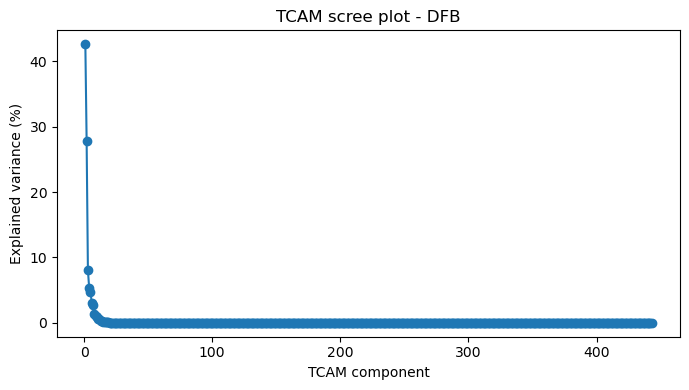

In [88]:
# =========================
# [15] SCREE PLOT
# =========================
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(expl_var) + 1), expl_var.values * 100, marker="o")
plt.xlabel("TCAM component")
plt.ylabel("Explained variance (%)")
plt.title("TCAM scree plot - DFB")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/tcam_scree_dfb.png", dpi=200)
plt.show()

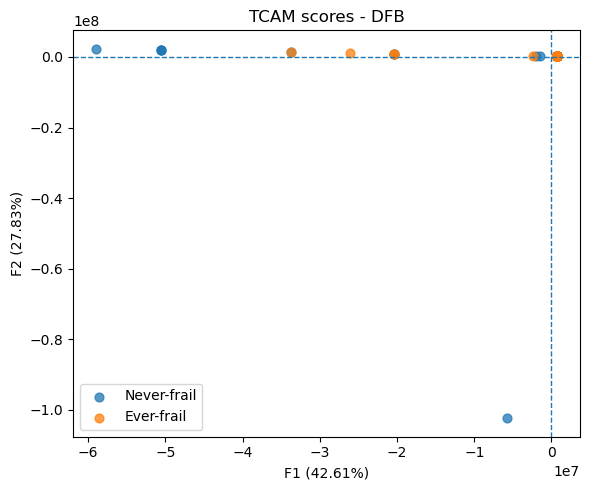

In [89]:
# =========================
# [16] SCATTER F1 VS F2
# =========================
plt.figure(figsize=(6, 5))

for grp in ["Never-frail", "Ever-frail"]:
    sub = scores_df[scores_df["frail_group"] == grp]
    plt.scatter(sub["F1"], sub["F2"], s=40, alpha=0.75, label=grp)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(f"F1 ({expl_var['F1']*100:.2f}%)")
plt.ylabel(f"F2 ({expl_var['F2']*100:.2f}%)")
plt.title("TCAM scores - DFB")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/tcam_scatter_F1_F2_dfb.png", dpi=200)
plt.show()

In [90]:
# =========================
# [17] T-TEST SU F1
# come nel paper proteomics
# =========================
f1_ever = scores_df.loc[scores_df["frail_group"] == "Ever-frail", "F1"].values
f1_never = scores_df.loc[scores_df["frail_group"] == "Never-frail", "F1"].values

t_stat, p_val = ttest_ind(f1_ever, f1_never, equal_var=False)

ttest_f1_df = pd.DataFrame({
    "group_1": ["Ever-frail"],
    "group_2": ["Never-frail"],
    "mean_F1_group1": [np.mean(f1_ever)],
    "mean_F1_group2": [np.mean(f1_never)],
    "t_stat": [t_stat],
    "p_value": [p_val]
})

display(ttest_f1_df)

ttest_f1_df.to_csv(f"{OUTDIR}/tables/tcam_ttest_F1_dfb.tsv", sep="\t", index=False)

,group_1,group_2,mean_F1_group1,mean_F1_group2,t_stat,p_value
0,Ever-frail,Never-frail,-80087.597006,24352.117291,-0.235231,0.814201


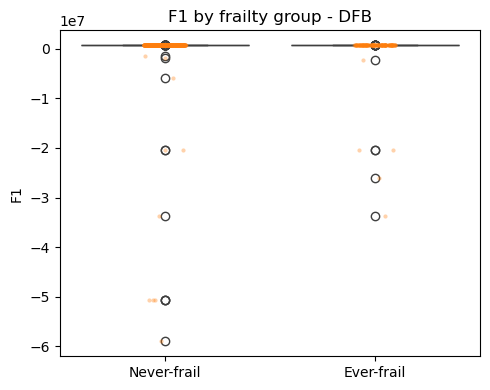

In [91]:
# =========================
# [18] BOXPLOT F1
# =========================
plt.figure(figsize=(5, 4))
tmp = scores_df[["F1", "frail_group"]].copy()

sns.boxplot(data=tmp, x="frail_group", y="F1")
sns.stripplot(data=tmp, x="frail_group", y="F1", alpha=0.35, size=3)

plt.title("F1 by frailty group - DFB")
plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/tcam_boxplot_F1_dfb.png", dpi=200)
plt.show()

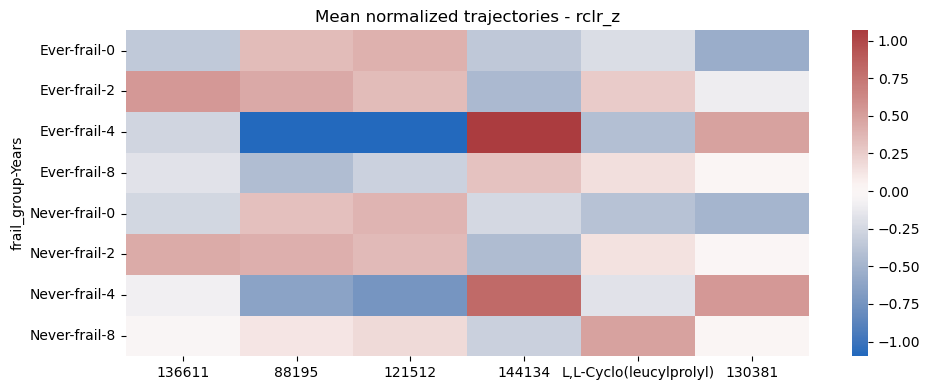

136611     88195    121512    144134  \
frail_group Years                                           
Ever-frail  0     -0.346802  0.341742  0.407580 -0.354333   
            2      0.540412  0.449863  0.348834 -0.461566   
            4     -0.263582 -1.094390 -1.098091  1.068761   
            8     -0.169726 -0.437395 -0.287828  0.308861   
Never-frail 0     -0.259164  0.318106  0.383388 -0.246865   
            2      0.440890  0.411186  0.357016 -0.440048   
            4     -0.089140 -0.628783 -0.735744  0.810485   
            8     -0.019702  0.124557  0.186752 -0.294375   

                   L,L-Cyclo(leucylprolyl)    130381  
frail_group Years                                     
Ever-frail  0                    -0.215167 -0.555049  
            2                     0.261667 -0.104422  
            4                    -0.414594  0.486541  
            8                     0.154905  0.012404  
Never-frail 0                    -0.400825 -0.496995  
            2                     0.144752 -0.001534  
            4                    -0.171110  0.535824  
            8                     0.492007  0.011516

In [83]:
# =========================
# [19] HEATMAP GRUPPO x VISITA
# =========================
heat_df = (
    df_norm_best[["Time", "Years", "frail_group"] + top_features]
    .groupby(["frail_group", "Years"])[top_features]
    .mean()
)

plt.figure(figsize=(10, 4))
sns.heatmap(heat_df, cmap="vlag", center=0)
plt.title(f"Mean normalized trajectories - {best_method}")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/heatmap_top_metabolites_{best_method}.png", dpi=200)
plt.show()

display(heat_df)